Brynn Dafoe
brynndafoe02
3109669210

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from itertools import combinations

Question 1.b.i
- make scatterplots of IVs in the dataset (use color to show Classes 0 and 1)

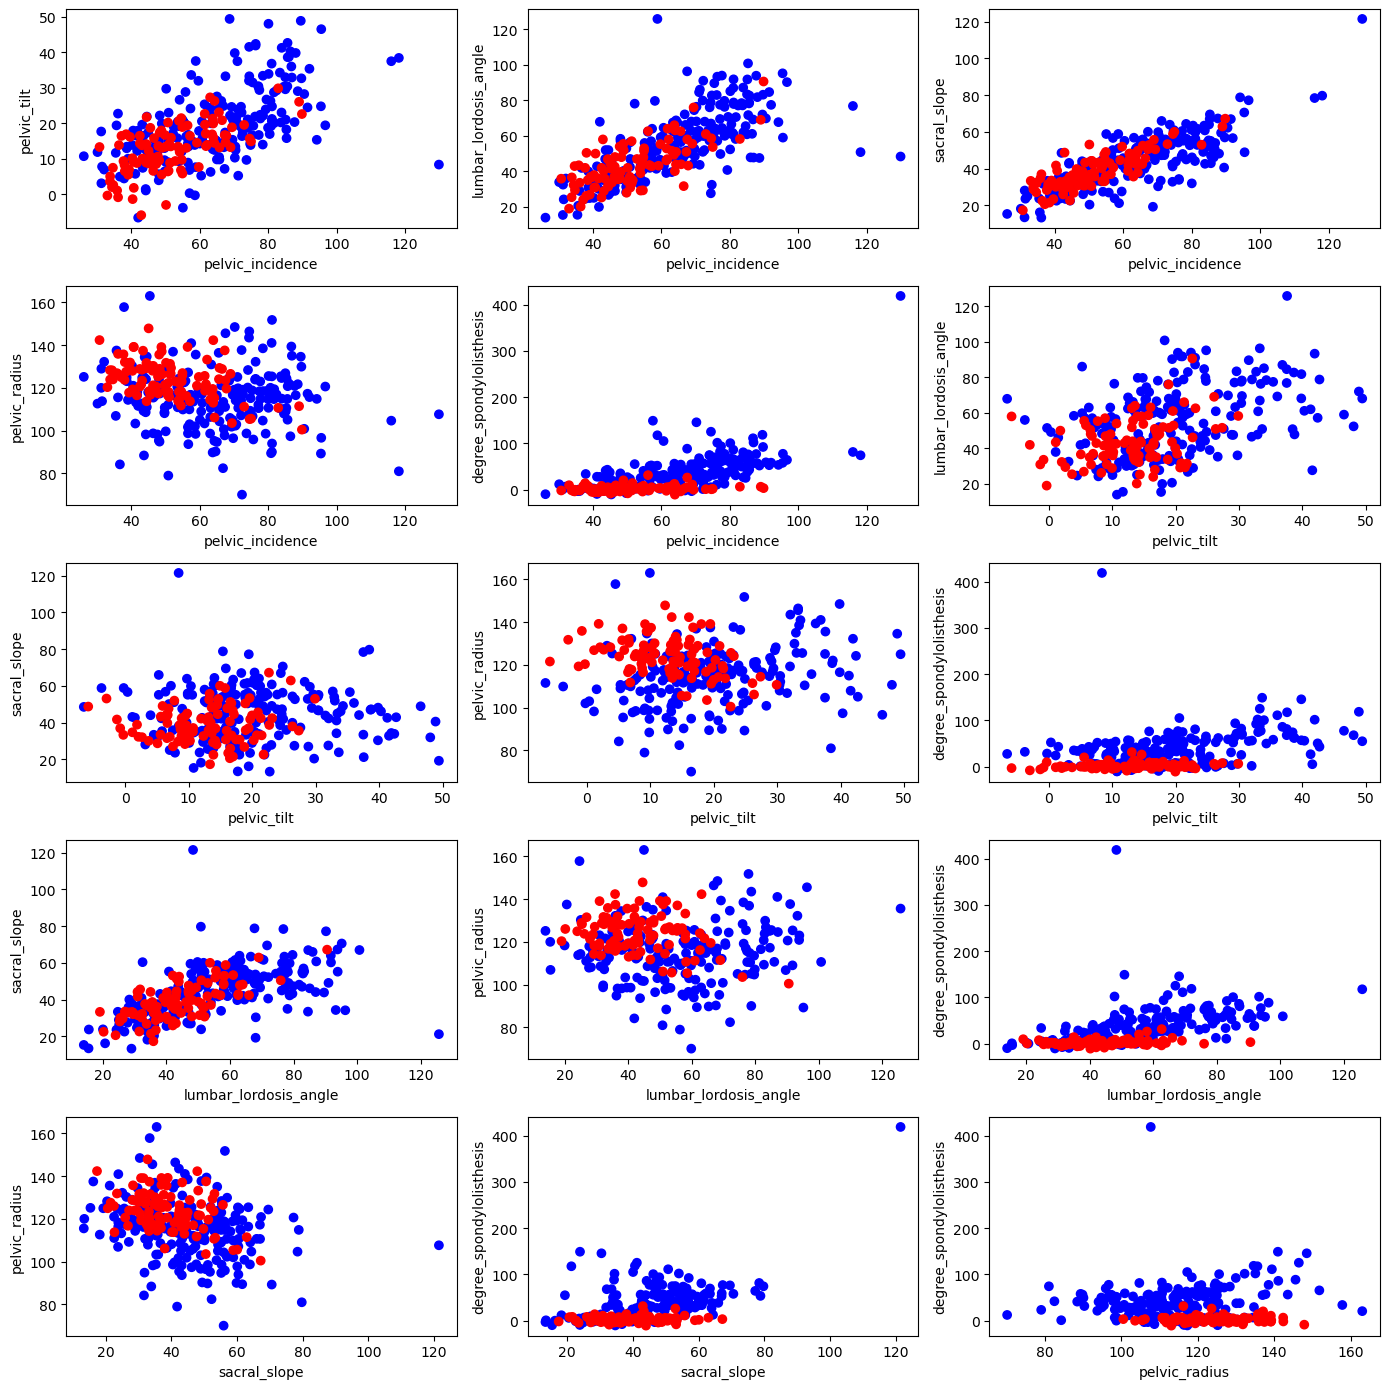

In [2]:
column_2C_df = pd.read_csv("../data/vertebral_column_data/column_2C.dat", sep = " ", header = None)
# the data is split up by whitespace so need to specify to break it into columns correctly, no header

column_2C_df.columns = ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis", "class"]

numeric_class_mapping = {"NO": 0, "AB": 1}
column_2C_df["class_binary"] = column_2C_df["class"].map(numeric_class_mapping)
# changes word classes to numeric to easily work with for plotting purposes

color_class_mapping = {0: "red", 1: "blue"}
column_2C_df["color"] = column_2C_df["class_binary"].map(color_class_mapping)

fig, axes = plt.subplots(5, 3, figsize = (14, 14))
# 5 x 3 because there are 15 pairs of IVs
axes = axes.flatten()

pairs_of_ivs = list(combinations(column_2C_df.columns[0:6], 2))
# looks like: [('pelvic_incidence', 'pelvic_tilt'), ('pelvic_incidence', 'lumbar_lordosis_angle'), etc.)
for i in range(len(pairs_of_ivs)):
    curr_x_axis = pairs_of_ivs[i][0]
    curr_y_axis = pairs_of_ivs[i][1]

    axes[i].scatter(column_2C_df[curr_x_axis], column_2C_df[curr_y_axis], c = column_2C_df["color"])
    axes[i].set_xlabel(curr_x_axis)
    axes[i].set_ylabel(curr_y_axis)

plt.tight_layout()
plt.show()

    

Question 1.b.ii
- make boxplots for each IV (use color to show Classes 0 and 1)

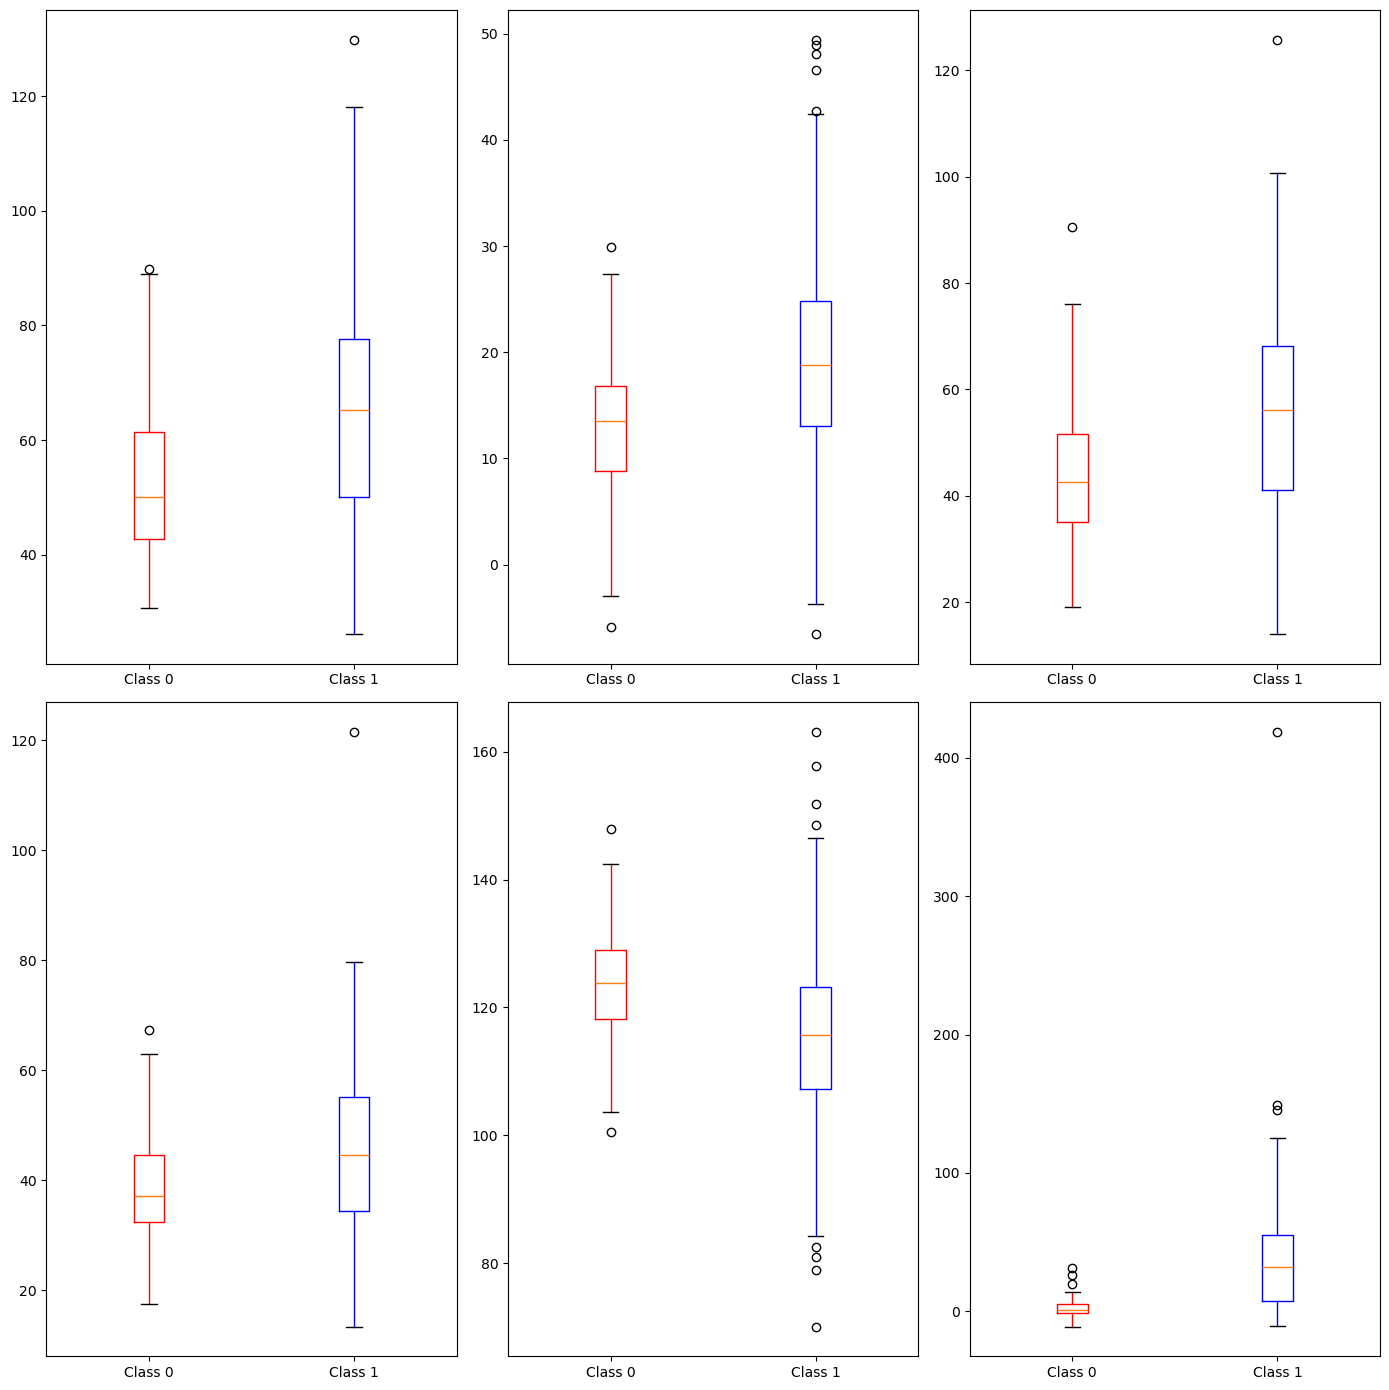

In [3]:
fig, axes = plt.subplots(2, 3, figsize = (14, 14))
# 2 x 3 because there are 6 IVs
axes = axes.flatten()

scatter_ivs = column_2C_df.columns[:6] # class is not an IV, need to exclude
i = 0
for iv in scatter_ivs:
    iv_class_0 = column_2C_df[column_2C_df["class_binary"] == 0][iv]
    iv_class_1 = column_2C_df[column_2C_df["class_binary"] == 1][iv]
    
    bp = axes[i].boxplot([iv_class_0, iv_class_1])
    axes[i].set_xticklabels(["Class 0", "Class 1"])

    bp["boxes"][0].set(color = "red")
    bp["whiskers"][0].set(color = "red")
    bp["whiskers"][1].set(color = "red")
    # whiskers 0 and 1 belong to class 0
    
    bp["boxes"][1].set(color = "blue")
    bp["whiskers"][2].set(color = "blue")
    bp["whiskers"][3].set(color = "blue")
    # whiskers 2 and 3 belong to class 1
    
    i += 1

plt.tight_layout()
plt.show()


Question 1.b.iii
- select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the training set, the rest of the data as the test set 

In [4]:
class_0 = column_2C_df[column_2C_df["class_binary"] == 0] #NO
class_1 = column_2C_df[column_2C_df["class_binary"] == 1] #AB

#.iloc[rows, columns]
training_0 = class_0.iloc[:70]
testing_0 = class_0.iloc[70:]

training_1 = class_1.iloc[:140]
testing_1 = class_1.iloc[140:]

training = pd.concat([training_0, training_1])
testing = pd.concat([testing_0, testing_1])

Question 1.c.i
- write code for k-nearest neighbors with Euclidean metric (or use a software package)

In [5]:
# X Train = training data / features
# Y Train = target values / labels

x_training = training.iloc[:, :6] # get all rows, first 6 columns (the features, no class)
y_training = training["class_binary"] # just the class

x_testing = testing.iloc[:, :6] # features
y_testing = testing["class_binary"] # class

def k_neighbors_classifier(k: int, x_train=None, y_train=None) -> list:
    if x_train is None:
        x_train = x_training
    if y_train is None:
        y_train = y_training
    
    k_n_n = KNeighborsClassifier(n_neighbors = k, metric = "euclidean")
    k_n_n.fit(x_train, y_train) # features, labels

    training_prediction = k_n_n.predict(x_train)
    testing_prediction = k_n_n.predict(x_testing)
    
    train_vs_test_pred = [training_prediction, testing_prediction]

    return train_vs_test_pred


Question 1.c.ii
- test all data in the test database with k nearest neighbors
- take decisions by majority polling
- plot train and test errors in terms of k for k -> {208, 205, ..., 7, 4, 1} in reverse order (can use smaller increments)
- which k* is the most suitable k among those values?
- calculate the confusion matrix, true positive rate, true negative rate, precision, and F1 score when k = k*

In [6]:
ks = list(range(1, 209, 3)) # 1, 4, 7, ..., 208

training_errors = []
testing_errors = []

for k in ks:
    train_vs_test_pred = k_neighbors_classifier(k) # [training_pred, testing_pred]
    
    # 1 - accuracy = error
    training_accuracy = accuracy_score(y_training, train_vs_test_pred[0])
    testing_accuracy = accuracy_score(y_testing, train_vs_test_pred[1])
    
    training_errors.append(1 - training_accuracy)
    testing_errors.append(1 - testing_accuracy)

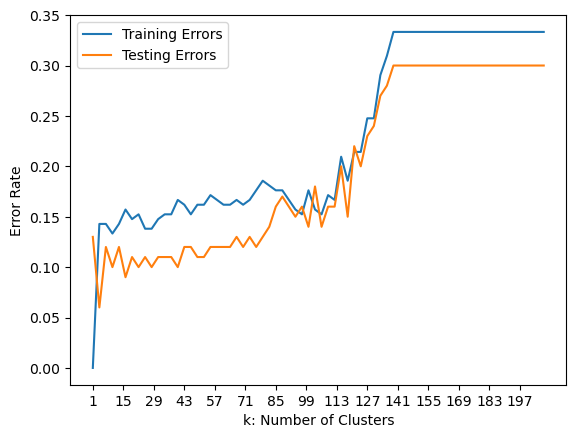

In [7]:
plt.plot(list(range(1, 209, 3)), training_errors, label = "Training Errors")
plt.plot(list(range(1, 209, 3)), testing_errors, label = "Testing Errors")

plt.xlabel("k: Number of Clusters")
plt.ylabel("Error Rate")
plt.xticks(range(1, 209, 14))
plt.legend()
plt.show()

In [8]:
smallest_error = min(testing_errors)
error_index = testing_errors.index(smallest_error)
most_suitable_k = ks[error_index]
print(f"The most suitable k is {most_suitable_k}.")

The most suitable k is 4.


In [9]:
best_k_pred = k_neighbors_classifier(most_suitable_k) # [training_pred, testing_pred]

#confusion matrix
conf_mat = confusion_matrix(y_testing, best_k_pred[1]) # (y_true, y_pred)
true_neg = conf_mat[0, 0]
false_pos = conf_mat[0, 1]
false_neg = conf_mat[1, 0]
true_pos = conf_mat[1, 1]
print(f"True Negative: {true_neg}\nFalse Positive: {false_pos}\nFalse Negative: {false_neg}\nTrue Positive: {true_pos}\n")

#true positive rate
true_pos_rate = true_pos / (true_pos + false_neg)
print(f"True Positive Rate: {true_pos_rate}")

#true negative rate
true_neg_rate = true_neg / (true_neg + false_pos)
print(f"True Negative Rate: {true_neg_rate}")

#precision
precision = true_pos / (true_pos + false_pos)
print(f"Precision: {precision}")
recall = true_pos / (true_pos + false_neg)

#F1 score when k = k*
f1_score = 2 * ((precision * recall) / (precision + recall))
print(f"F1 Score: {f1_score}")


True Negative: 25
False Positive: 5
False Negative: 1
True Positive: 69

True Positive Rate: 0.9857142857142858
True Negative Rate: 0.8333333333333334
Precision: 0.9324324324324325
F1 Score: 0.9583333333333333


Question 1.c.iii
- computation time depends on size of the training set, one may use a subset of the training set
- plot the best test error rate (using test data created in 1.b.iii), which is obtained by some value of k, against the size of the training set, when the size of training set is N -> {10, 20, 30, ..., 210} (can use smaller increments of N)
- for each N, select your training set by choosing the first floor_func(N/3) rows of Class 0 and the first N - floor_func(N/3) rows of Class 1 in the training set created in 1.b.iii
- also, for each N, select the optimal k from a set starting from k = 1, increasing by 5 (ex: N = 200, the optimal k is selected from {1, 6, 11, ..., 196})(this plot is called a Learning Curve)

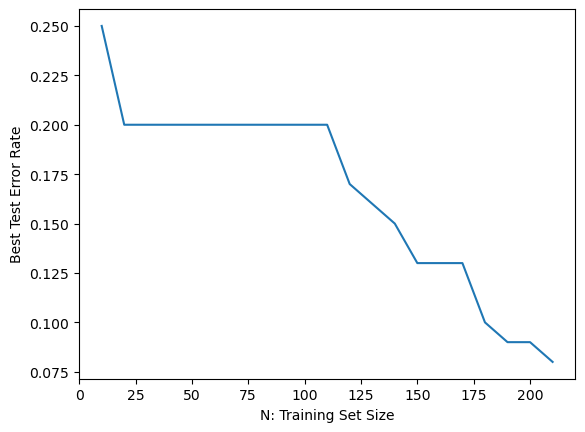

In [10]:
n_size = list(range(10, 211, 10))
# training_0 -> Class 0 training set from 1.b.iii
# training_1 -> Class 1 training set 
# x_testing -> x and y training sets from above, will reuse
# y_testing ^

best_error = 1 # starting at the worst possible error
best_error_list = []

for n in n_size:
    class_0_new_size = n // 3
    class_1_new_size = n - class_0_new_size

    new_training_0 = training_0.iloc[:class_0_new_size]
    new_training_1 = training_1.iloc[:class_1_new_size]
    new_training = pd.concat([new_training_0, new_training_1])

    new_x_training = new_training.iloc[:, :6]
    new_y_training = new_training["class_binary"]

    new_ks = list(range(1, n, 5))
    
    for new_k in new_ks:
        new_train_vs_test_pred = k_neighbors_classifier(new_k, new_x_training, new_y_training) # [training_pred, testing_pred]

        testing_accuracy = accuracy_score(y_testing, new_train_vs_test_pred[1])
        testing_error = 1 - testing_accuracy

        if testing_error < best_error:
            best_error = testing_error
            
    best_error_list.append(best_error)
    
plt.plot(n_size, best_error_list)
plt.xlabel("N: Training Set Size")
plt.ylabel("Best Test Error Rate")
plt.show()


Question 1.d
- replace the Euclidean metric with the following metrics and test them (can use sklearn.neighbors.DistanceMetric)
- summarise the test errors (ie: when k = k*) in a table
- use all of your training data and select the best k when {1, 6, 11, ..., 196}

In [11]:
# x_training -> features
# y_training -> labels
# x_testing -> features
# y_testing -> labels

# remaking the function I made earlier to better fit this question
def k_neighbors_classifier_diff_metric(k: int, dist_metric: str, p=None) -> list:
    if p is None:
        k_n_n = KNeighborsClassifier(n_neighbors = k, metric = dist_metric)
    else:
        k_n_n = KNeighborsClassifier(n_neighbors = k, metric = dist_metric, p = p)
    
    k_n_n.fit(x_training, y_training) # features, labels

    training_prediction = k_n_n.predict(x_training)
    testing_prediction = k_n_n.predict(x_testing)
    
    train_vs_test_pred = [training_prediction, testing_prediction]

    return train_vs_test_pred

Question 1.d.i.A
- MANHATTAN DISTANCE
- - Minkowski Distance
- - which becomes Manhattan Distance with p = 1

In [12]:
ks_q1d = list(range(1, 197, 5))

manh_best_k = None # to save best k for later questions
manh_best_test_error = 1
manh_best_te_list = []

for k_q1d in ks_q1d:
    manh_train_test_pred = k_neighbors_classifier_diff_metric(k_q1d, "manhattan")
    # stating the metric is manhattan sets p=1 automatically 
    # ^ returns [training pred, testing pred]

    manh_test_acc = accuracy_score(y_testing, manh_train_test_pred[1])
    manh_test_err = 1 - manh_test_acc

    if manh_test_err < manh_best_test_error:
        manh_best_test_error = manh_test_err
        manh_best_k = k_q1d
        
    manh_best_te_list.append(manh_best_test_error)

print(f"The best k is {manh_best_k}.")

The best k is 6.


Question 1.d.i.B
- MINKOWSKI DISTANCE
- - with log10(p) -> {0.1, 0.2, ..., 1}
- - in this case, use the k* you found from the Manhattan distance in 1.d.ia
- - what is the best log10(p)?

In [13]:
mink_best_test_error = 1
mink_best_te_list = []

log10p_equals = np.arange(.1, 1.1, .1) # [0.1, 0.2, 0.3, ..., 1]
ps = []

best_p = None

for i in log10p_equals:
    calc_p = 10 ** i
    ps.append(calc_p)

for p in ps:
    mink_train_test_pred = k_neighbors_classifier_diff_metric(manh_best_k, "minkowski", p)
    # using best k saved from manhattan

    mink_test_acc = accuracy_score(y_testing, mink_train_test_pred[1])
    mink_test_err = 1 - mink_test_acc

    if mink_test_err < mink_best_test_error:
        mink_best_test_error = mink_test_err
        best_p = p
        
    mink_best_te_list.append(mink_best_test_error)

print(f"The best log10(p) is log10({best_p}).")

The best log10(p) is log10(3.981071705534973).


Question 1.d.i.C
- CHEBYSHEV DISTANCE
- - Minkowski Distance
- - which becomes Chebyshev Distance with p -> infinity

In [17]:
cheb_best_k = None # to save best k for later questions
cheb_best_test_error = 1
cheb_best_te_list = []

for k_q1d2 in ks_q1d:
    cheb_train_test_pred = k_neighbors_classifier_diff_metric(k_q1d2, "chebyshev")
    # stating the metric is chebyshev sets p=infinity automatically 
    # ^ returns [training pred, testing pred]

    cheb_test_acc = accuracy_score(y_testing, cheb_train_test_pred[1])
    cheb_test_err = 1 - cheb_test_acc

    if cheb_test_err < cheb_best_test_error:
        cheb_best_test_error = cheb_test_err
        cheb_best_k = k_q1d2
        
    cheb_best_te_list.append(cheb_best_test_error)

print(f"The best k is {cheb_best_k}.")

The best k is 16.


Question 1.d.ii
- MAHALANOBIS DISTANCE

In [ ]:
cov_matrix = np.cov(X_train, rowvar=False)
inv_cov_matrix = np.linalg.pinv(cov_matrix)